# Artificial Neural Networks (ANN): A Comprehensive Guide

Welcome to this in-depth guide on **Artificial Neural Networks (ANN)**. Every section pairs theory with a working implementation so you can see each concept in action.

## Table of Contents
1. [Introduction](#1.-Introduction)
2. [Biological Motivation](#2.-Biological-Motivation)
3. [Perceptrons](#3.-Perceptrons)
4. [Representational Power of Perceptrons](#4.-Representational-Power-of-Perceptrons)
5. [Perceptron Training Rule](#5.-Perceptron-Training-Rule)
6. [Gradient Descent and the Delta Rule](#6.-Gradient-Descent-and-the-Delta-Rule)
7. [Stochastic Gradient Descent (SGD)](#7.-Stochastic-Gradient-Descent)
8. [Backpropagation Algorithm](#8.-Backpropagation-Algorithm)
9. [Momentum](#9.-Momentum)
10. [Feed-Forward Networks and Hidden Layers](#10.-Feed-Forward-Networks-and-Hidden-Layers)
11. [Generalization, Overfitting, and Stopping Criteria](#11.-Generalization,-Overfitting,-and-Stopping-Criteria)
12. [Hyperparameters and Tuning](#12.-Hyperparameters-and-Tuning)
13. [Culminating Example – Facial Recognition (30×32)](#13.-Culminating-Example)


---
## 1. Introduction

**Artificial Neural Networks (ANNs)** are a family of machine-learning models loosely inspired by biological neural networks. They consist of layers of interconnected nodes ("neurons") that learn to map inputs to outputs by adjusting the strength of those connections during training.

### Why ANNs matter
| Property | Benefit |
|---|---|
| **Universal approximation** | A sufficiently large network can approximate *any* continuous function |
| **Automatic feature learning** | Hidden layers discover useful representations from raw data |
| **Flexibility** | The same architecture handles classification, regression, generation, etc. |

### Core workflow
1. **Design** the architecture (layers, neurons, activations).
2. **Initialize** weights (often small random values).
3. **Forward pass** – compute output from inputs.
4. **Compute loss** – measure how wrong the output is.
5. **Backward pass** – compute gradients of the loss w.r.t. each weight.
6. **Update weights** – move in the direction that reduces the loss.
7. Repeat steps 3–6 over many epochs.

Let's set up our imports for the entire notebook:


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

print("Environment ready ✓")
print(f"NumPy version: {np.__version__}")


Environment ready ✓
NumPy version: 2.3.4


---
## 2. Biological Motivation

ANNs draw inspiration from the **nervous system**:

| Biological Component | Artificial Counterpart |
|---|---|
| **Neuron** (cell body / soma) | A computational unit (node) |
| **Dendrites** (input channels) | Input connections with weights |
| **Axon** (output channel) | Output of the node |
| **Synapse** (junction between neurons) | Weight on a connection |
| **Neurotransmitter strength** | Magnitude of the weight |

### How a biological neuron fires
1. **Dendrites** collect electrical signals from other neurons.
2. The **soma** sums all incoming signals.
3. If the sum exceeds a **threshold**, the neuron fires an action potential down the **axon**.
4. That signal crosses a **synapse** (with some strength) and becomes input to the next neuron.

An artificial neuron mirrors this: it computes a **weighted sum** of its inputs, adds a **bias**, and passes the result through an **activation function** (the threshold analogue).

Let's visualize a single artificial neuron:
![Perceptron with Biological Neuron](perceptron-with-neuron_1.png)


---
## 3. Perceptrons

The **perceptron** (Rosenblatt, 1957) is the simplest neural network – a single neuron that performs binary classification.

### Mathematical definition

Given input vector $\mathbf{x} = (x_1, x_2, \dots, x_n)$ and weight vector $\mathbf{w} = (w_1, w_2, \dots, w_n)$, the perceptron output is:

$$o(\mathbf{x}) = \text{sgn}\!\left(\sum_{i=0}^{n} w_i x_i\right)$$

where $x_0 = 1$ (bias input), $w_0 = b$ (bias weight), and:

$$\text{sgn}(z) = \begin{cases} +1 & \text{if } z \ge 0 \\ -1 & \text{otherwise} \end{cases}$$

Geometrically, the equation $\mathbf{w} \cdot \mathbf{x} = 0$ defines a **decision hyperplane** that separates the input space into two half-spaces.

### Implementation

Below we build a `Perceptron` class from scratch. Key implementation details:
- We prepend a 1 to every input vector so the bias is absorbed into the weight vector.
- `predict` computes the sign of the dot product.


In [30]:
class Perceptron:
    """Single-neuron binary classifier using the sign activation."""

    def __init__(self, n_features, lr=0.1):
        # Initialize weights to small random values (including bias w_0)
        self.weights = np.zeros(n_features + 1)  # +1 for the bias term w_0
        self.lr = lr

    def _add_bias(self, x):
        """Prepend x_0 = 1 so bias is handled as w_0 * 1."""
        return np.insert(x, 0, 1)

    def net_input(self, x):
        """Compute the weighted sum: w · x."""
        return np.dot(self.weights, self._add_bias(x))

    def predict(self, x):
        """Apply the sign activation function."""
        return 1 if self.net_input(x) >= 0 else -1

# Quick sanity check
p = Perceptron(2)
print("Initial weights:", p.weights)
print("Prediction for [0, 0]:", p.predict(np.array([0, 0])))
print("Prediction for [1, 1]:", p.predict(np.array([1, 1])))


Initial weights: [0. 0. 0.]
Prediction for [0, 0]: 1
Prediction for [1, 1]: 1


---
## 4. Representational Power of Perceptrons

A perceptron can represent **only linearly separable** functions – those whose positive and negative examples can be separated by a hyperplane.

### Boolean functions a single perceptron CAN learn

| Function | Linearly separable? |
|---|---|
| AND | ✅ Yes |
| OR | ✅ Yes |
| NAND | ✅ Yes |
| NOR | ✅ Yes |
| **XOR** | ❌ **No** |

### Why XOR fails
For XOR, the positive examples $(0,1)$ and $(1,0)$ lie diagonally across the negative examples $(0,0)$ and $(1,1)$. No single straight line can separate them.

**This was a key criticism** by Minsky & Papert (1969) and contributed to the first "AI Winter". The solution is multi-layer networks, which we'll cover later.

Let's visualize this:


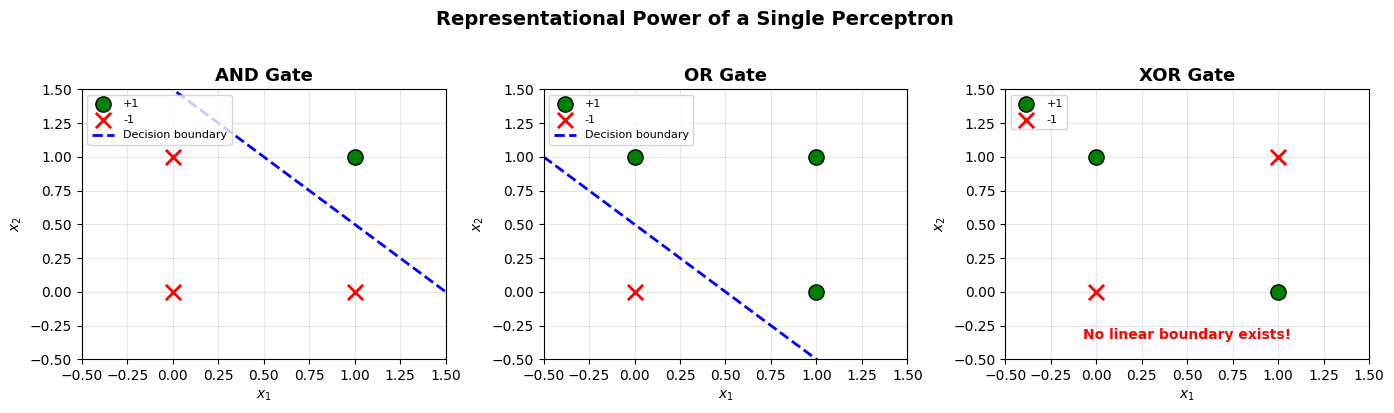

In [10]:
# Visualize AND, OR, XOR to show linear separability
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels_map = {
    'AND': np.array([-1, -1, -1, 1]),
    'OR':  np.array([-1, 1, 1, 1]),
    'XOR': np.array([-1, 1, 1, -1]),
}

for ax, (name, labels) in zip(axes, labels_map.items()):
    pos = data[labels == 1]
    neg = data[labels == -1]
    ax.scatter(pos[:, 0], pos[:, 1], c='green', s=120, marker='o', label='+1', edgecolors='black', zorder=5)
    ax.scatter(neg[:, 0], neg[:, 1], c='red', s=120, marker='x', label='-1', linewidths=2, zorder=5)

    # Draw a separating line for AND and OR (not possible for XOR)
    x_line = np.linspace(-0.5, 1.5, 100)
    if name == 'AND':
        # Decision boundary: x1 + x2 = 1.5
        ax.plot(x_line, 1.5 - x_line, 'b--', lw=2, label='Decision boundary')
    elif name == 'OR':
        # Decision boundary: x1 + x2 = 0.5
        ax.plot(x_line, 0.5 - x_line, 'b--', lw=2, label='Decision boundary')
    else:
        ax.text(0.5, -0.35, 'No linear boundary exists!', ha='center', color='red',
                fontsize=10, fontweight='bold')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f'{name} Gate', fontsize=13, fontweight='bold')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Representational Power of a Single Perceptron", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Perceptron Training Rule

The perceptron learning algorithm updates weights based on misclassified examples:

$$w_i \leftarrow w_i + \eta \,(t - o)\, x_i$$

where:
- $t$ = target label ($+1$ or $-1$)
- $o$ = predicted label
- $\eta$ = learning rate

### Key properties
- When $t = o$ (correct prediction): $\Delta w_i = 0$ → no update.
- When $t \ne o$: the update nudges the decision boundary toward the misclassified point.
- **Convergence theorem**: If the data is linearly separable, the perceptron learning algorithm converges in a finite number of steps (regardless of initialization).

Let's train a perceptron on the AND gate and track convergence:


✓ Converged at epoch 3
Final weights: [-0.4  0.4  0.2]
Predictions: [-1, -1, -1, 1]
Expected:     [np.int64(-1), np.int64(-1), np.int64(-1), np.int64(1)]


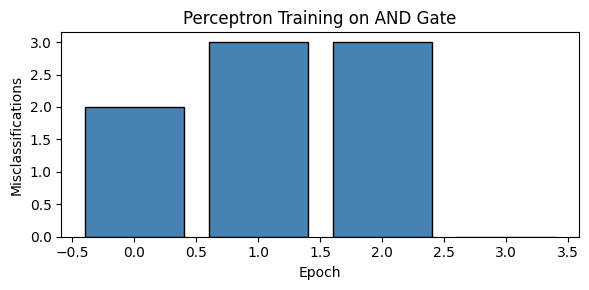

In [11]:
def train_perceptron(perceptron, X, y, epochs=20):
    """Train using the perceptron learning rule. Returns history of weight snapshots."""
    history = []
    for epoch in range(epochs):
        n_errors = 0
        for xi, target in zip(X, y):
            prediction = perceptron.predict(xi)
            if prediction != target:
                error = target - prediction  # either +2 or -2
                update = perceptron.lr * error
                perceptron.weights[0] += update * 1     # bias update
                perceptron.weights[1:] += update * xi   # weight update
                n_errors += 1
        history.append((epoch, n_errors, perceptron.weights.copy()))
        if n_errors == 0:
            print(f"✓ Converged at epoch {epoch}")
            break
    return history

# --- Train on AND ---
AND_X = np.array([[0,0], [0,1], [1,0], [1,1]])
AND_y = np.array([-1, -1, -1, 1])

p_and = Perceptron(2, lr=0.1)
history = train_perceptron(p_and, AND_X, AND_y)

print(f"Final weights: {p_and.weights}")
print(f"Predictions: {[p_and.predict(x) for x in AND_X]}")
print(f"Expected:     {list(AND_y)}")

# Plot errors per epoch
epochs_list = [h[0] for h in history]
errors_list = [h[1] for h in history]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(epochs_list, errors_list, color='steelblue', edgecolor='black')
ax.set_xlabel('Epoch')
ax.set_ylabel('Misclassifications')
ax.set_title('Perceptron Training on AND Gate')
plt.tight_layout()
plt.show()


---
## 6. Gradient Descent and the Delta Rule

### Limitation of the perceptron rule
The perceptron rule only works for **linearly separable** data. If the data is not separable, the algorithm oscillates forever.

### The Delta Rule (Widrow–Hoff / Adaline)
To handle non-separable data gracefully, we:
1. Replace the hard sign function with the **linear** (unthresholded) output: $o = \mathbf{w} \cdot \mathbf{x}$.
2. Define a differentiable **loss function** — the Sum of Squared Errors (SSE):

$$E(\mathbf{w}) = \frac{1}{2}\sum_{d \in D}(t_d - o_d)^2$$

3. Update weights by following the **negative gradient** of $E$:

$$\Delta w_i = -\eta \frac{\partial E}{\partial w_i} = \eta \sum_{d \in D} (t_d - o_d)\, x_{id}$$

### Batch Gradient Descent algorithm
```
Initialize weights w randomly
Repeat until convergence:
    Compute gradient over ALL training examples
    Update: w ← w + η · Σ_d (t_d − o_d) · x_d
```

### Visualizing the error surface
For a 2-weight problem, $E(\mathbf{w})$ is a **paraboloid** (bowl-shaped surface) with a single global minimum. Gradient descent slides down this bowl.


Learned: y ≈ 2.440·x + 1.091
True:    y = 2.500·x + 1.000


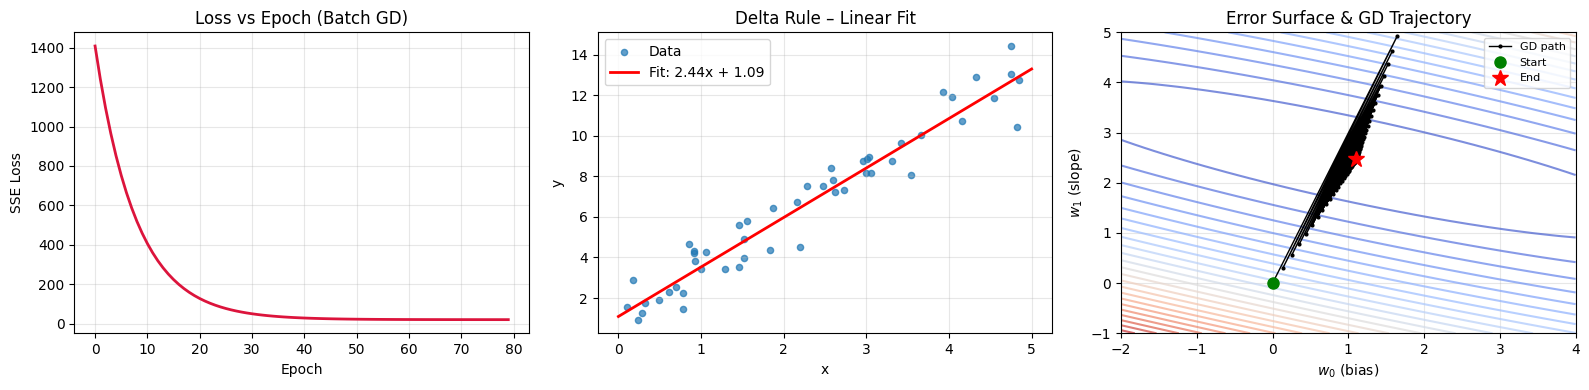

In [12]:
# Delta Rule: Linear regression via batch gradient descent (from scratch)
# We'll fit a simple linear model y = w1*x + w0 on synthetic data.

np.random.seed(42)
X_lin = np.random.uniform(0, 5, 50)
y_lin = 2.5 * X_lin + 1.0 + np.random.normal(0, 1, 50)  # true: y = 2.5x + 1 + noise

# We'll track how weights evolve over epochs using batch gradient descent
w0, w1 = 0.0, 0.0   # initial weights (bias w0, slope w1)
lr = 0.005
n_epochs = 80
loss_history = []
w_history = []

for epoch in range(n_epochs):
    # Forward pass (linear unit): o_d = w0 + w1 * x_d
    predictions = w0 + w1 * X_lin
    errors = y_lin - predictions

    # Loss = 0.5 * sum of squared errors
    loss = 0.5 * np.sum(errors ** 2)
    loss_history.append(loss)
    w_history.append((w0, w1))

    # Gradient (batch): sum over all examples
    grad_w0 = -np.sum(errors)              # dE/dw0
    grad_w1 = -np.sum(errors * X_lin)      # dE/dw1

    # Update
    w0 -= lr * grad_w0
    w1 -= lr * grad_w1

print(f"Learned: y ≈ {w1:.3f}·x + {w0:.3f}")
print(f"True:    y = 2.500·x + 1.000")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Loss curve
axes[0].plot(loss_history, color='crimson', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('SSE Loss')
axes[0].set_title('Loss vs Epoch (Batch GD)'); axes[0].grid(True, alpha=0.3)

# 2) Data + fitted line
axes[1].scatter(X_lin, y_lin, s=20, alpha=0.7, label='Data')
x_plot = np.linspace(0, 5, 100)
axes[1].plot(x_plot, w1 * x_plot + w0, 'r-', lw=2, label=f'Fit: {w1:.2f}x + {w0:.2f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Delta Rule – Linear Fit'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3) Weight trajectory on error surface (contour plot)
w0_range = np.linspace(-2, 4, 100)
w1_range = np.linspace(-1, 5, 100)
W0, W1 = np.meshgrid(w0_range, w1_range)
Z = np.zeros_like(W0)
for i in range(len(X_lin)):
    Z += (y_lin[i] - (W0 + W1 * X_lin[i])) ** 2
Z *= 0.5

axes[2].contour(W0, W1, Z, levels=30, cmap='coolwarm', alpha=0.7)
wh = np.array(w_history)
axes[2].plot(wh[:, 0], wh[:, 1], 'k.-', markersize=4, lw=1, label='GD path')
axes[2].plot(wh[0, 0], wh[0, 1], 'go', markersize=8, label='Start')
axes[2].plot(wh[-1, 0], wh[-1, 1], 'r*', markersize=12, label='End')
axes[2].set_xlabel('$w_0$ (bias)'); axes[2].set_ylabel('$w_1$ (slope)')
axes[2].set_title('Error Surface & GD Trajectory'); axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Stochastic Gradient Descent

**Batch GD** computes the gradient over *all* examples before each update — expensive for large datasets.

**Stochastic Gradient Descent (SGD)** updates after each *single* example:

$$\Delta w_i = \eta\,(t_d - o_d)\,x_{id} \quad \text{(for one randomly chosen example } d\text{)}$$

**Mini-batch GD** is a compromise: update after every small batch (e.g., 32 examples).

| Method | Pros | Cons |
|---|---|---|
| **Batch GD** | Stable, smooth convergence | Slow per step; memory-heavy |
| **SGD** | Fast per step; can escape local minima | Noisy; needs LR scheduling |
| **Mini-batch** | Balanced speed & stability | Adds batch-size hyperparameter |

Let's compare Batch GD vs SGD on the same data:


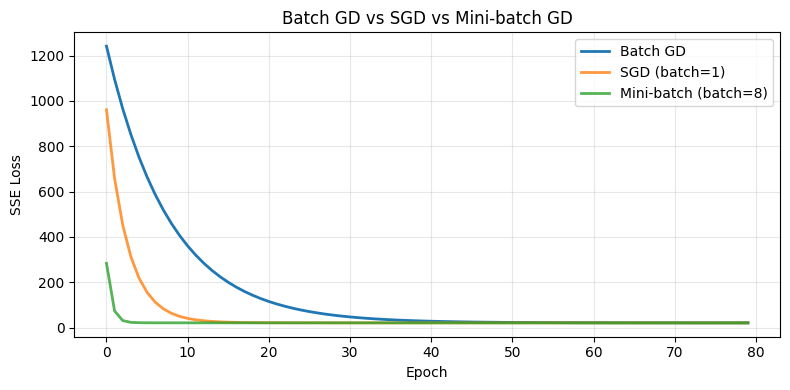

• Batch GD is smooth but each step is expensive (uses all data).
• SGD is noisy but fast per step and can escape shallow local minima.
• Mini-batch balances both: reasonably smooth yet computationally efficient.


In [13]:
# Compare Batch GD vs SGD on the same linear-regression problem
np.random.seed(42)

def run_gd(X, y, lr, epochs, mode='batch', batch_size=1):
    w0, w1 = 0.0, 0.0
    losses = []
    for epoch in range(epochs):
        if mode == 'batch':
            preds = w0 + w1 * X
            errs = y - preds
            w0 += lr * np.sum(errs)
            w1 += lr * np.sum(errs * X)
        else:  # stochastic or mini-batch
            indices = np.random.permutation(len(X))
            for start in range(0, len(X), batch_size):
                idx = indices[start:start+batch_size]
                preds = w0 + w1 * X[idx]
                errs = y[idx] - preds
                w0 += lr * np.sum(errs)
                w1 += lr * np.sum(errs * X[idx])
        preds_all = w0 + w1 * X
        losses.append(0.5 * np.sum((y - preds_all) ** 2))
    return losses

losses_batch = run_gd(X_lin, y_lin, lr=0.005, epochs=80, mode='batch')
losses_sgd   = run_gd(X_lin, y_lin, lr=0.0005, epochs=80, mode='sgd', batch_size=1)
losses_mini  = run_gd(X_lin, y_lin, lr=0.002, epochs=80, mode='sgd', batch_size=8)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_batch, label='Batch GD', lw=2)
ax.plot(losses_sgd,   label='SGD (batch=1)', lw=2, alpha=0.8)
ax.plot(losses_mini,  label='Mini-batch (batch=8)', lw=2, alpha=0.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('SSE Loss')
ax.set_title('Batch GD vs SGD vs Mini-batch GD')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("• Batch GD is smooth but each step is expensive (uses all data).")
print("• SGD is noisy but fast per step and can escape shallow local minima.")
print("• Mini-batch balances both: reasonably smooth yet computationally efficient.")


---
## 8. Backpropagation Algorithm

For multi-layer networks, we can't simply apply the Delta Rule because we don't know the "target" for hidden neurons. **Backpropagation** (Rumelhart, Hinton & Williams, 1986) solves this using the **chain rule** of calculus.

### Algorithm outline
1. **Forward pass**: Compute outputs layer by layer.
2. **Compute output error**: $\delta_k = (t_k - o_k)\,f'(\text{net}_k)$
3. **Propagate error backward**: For hidden unit $h$:  
   $\delta_h = f'(\text{net}_h)\,\sum_k w_{hk}\,\delta_k$
4. **Update weights**: $\Delta w_{ij} = \eta\,\delta_j\,x_i$

We use the **sigmoid** activation $\sigma(z) = \frac{1}{1+e^{-z}}$ whose derivative is conveniently $\sigma'(z) = \sigma(z)\,(1-\sigma(z))$.

### Implementation: Solving XOR with a 2-layer network
XOR cannot be solved by a single perceptron, but a network with **one hidden layer** (2 hidden neurons) can learn it perfectly.


  Epoch     0  Loss: 0.134319
  Epoch  1000  Loss: 0.000591
  Epoch  2000  Loss: 0.000230
  Epoch  3000  Loss: 0.000139
  Epoch  4000  Loss: 0.000099

Predictions: [0.012 0.989 0.985 0.011]
Targets:     [0. 1. 1. 0.]


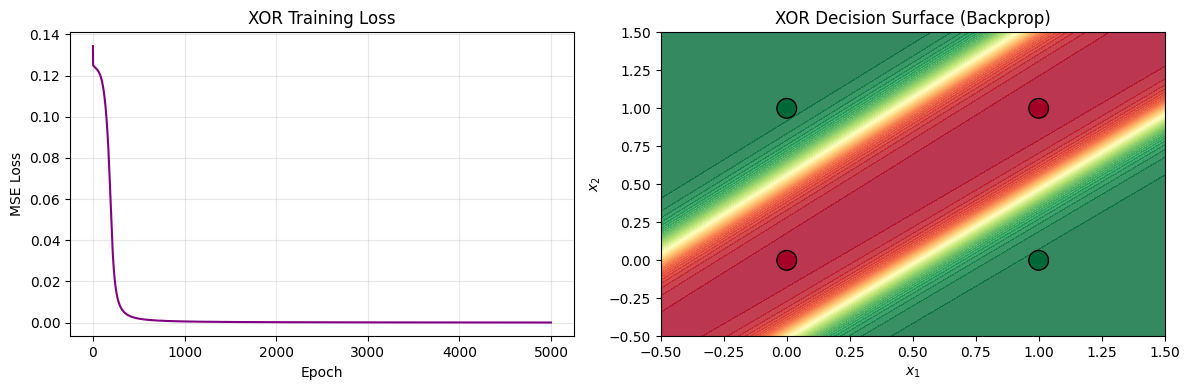

In [14]:
# ---------- Helper functions ----------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(a):
    """Derivative given the *activated* output a = sigmoid(z)."""
    return a * (1.0 - a)

# ---------- 2-Layer MLP from scratch ----------
class MLP:
    """Minimal multi-layer perceptron: input → hidden → output."""

    def __init__(self, n_in, n_hidden, n_out, lr=0.5):
        # Xavier initialization
        self.W1 = np.random.randn(n_in, n_hidden) * np.sqrt(2.0 / n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_out) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
        self.losses = []

    def forward(self, X):
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        # Output layer error
        delta2 = (self.a2 - y) * sigmoid_deriv(self.a2)      # (m, n_out)
        # Hidden layer error (backpropagated)
        delta1 = (delta2 @ self.W2.T) * sigmoid_deriv(self.a1)  # (m, n_hidden)

        # Gradients
        dW2 = self.a1.T @ delta2 / m
        db2 = np.sum(delta2, axis=0, keepdims=True) / m
        dW1 = X.T @ delta1 / m
        db1 = np.sum(delta1, axis=0, keepdims=True) / m

        # Update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=5000, verbose=True):
        for ep in range(epochs):
            out = self.forward(X)
            loss = 0.5 * np.mean((y - out) ** 2)
            self.losses.append(loss)
            self.backward(X, y)
            if verbose and ep % 1000 == 0:
                print(f"  Epoch {ep:5d}  Loss: {loss:.6f}")

# --- Train on XOR ---
XOR_X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
XOR_y = np.array([[0],[1],[1],[0]], dtype=float)

mlp_xor = MLP(n_in=2, n_hidden=4, n_out=1, lr=5.0)
mlp_xor.fit(XOR_X, XOR_y, epochs=5000)

preds = mlp_xor.forward(XOR_X)
print(f"\nPredictions: {preds.flatten().round(3)}")
print(f"Targets:     {XOR_y.flatten()}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp_xor.losses, color='purple', lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('XOR Training Loss'); axes[0].grid(True, alpha=0.3)

# Decision surface
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = mlp_xor.forward(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, zz, levels=50, cmap='RdYlGn', alpha=0.8)
axes[1].scatter(XOR_X[:, 0], XOR_X[:, 1], c=XOR_y.flatten(), s=200,
                cmap='RdYlGn', edgecolors='black', zorder=5)
axes[1].set_title('XOR Decision Surface (Backprop)')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()


---
## 9. Momentum

Standard gradient descent can:
- Oscillate in ravines (steep narrow valleys).
- Get stuck in shallow local minima or saddle points.

**Momentum** smooths the updates by adding a fraction of the previous update:

$$v_t = \alpha \, v_{t-1} + \eta \, \nabla E$$
$$\mathbf{w} \leftarrow \mathbf{w} - v_t$$

where $\alpha \in [0, 1)$ is the **momentum coefficient** (typically 0.9).

### Intuition
Think of a ball rolling downhill:
- Without momentum: the ball changes direction at every bump.
- With momentum: the ball accumulates velocity and powers through small bumps.

Let's compare GD with and without momentum on a 2D optimization landscape:


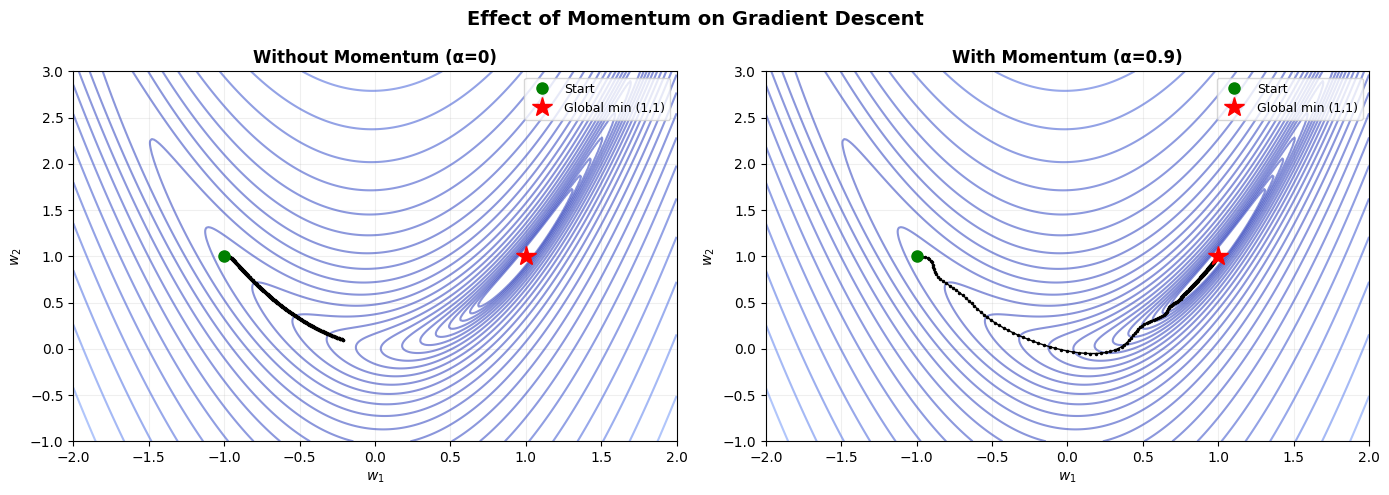

With momentum, the optimizer reaches the minimum in fewer steps and oscillates less.


In [15]:
# 2D optimization: comparing plain GD vs GD with momentum
# We'll minimize the Rosenbrock-like function: f(w1,w2) = (1-w1)^2 + 10*(w2-w1^2)^2

def rosenbrock(w):
    return (1 - w[0])**2 + 10 * (w[1] - w[0]**2)**2

def rosenbrock_grad(w):
    dw1 = -2*(1 - w[0]) - 40*w[0]*(w[1] - w[0]**2)
    dw2 = 20*(w[1] - w[0]**2)
    return np.array([dw1, dw2])

def optimize(lr, momentum, n_steps, start):
    w = np.array(start, dtype=float)
    v = np.zeros(2)
    path = [w.copy()]
    for _ in range(n_steps):
        g = rosenbrock_grad(w)
        v = momentum * v + lr * g
        w = w - v
        path.append(w.copy())
    return np.array(path)

path_no_mom  = optimize(lr=0.002, momentum=0.0, n_steps=300, start=[-1.0, 1.0])
path_mom     = optimize(lr=0.002, momentum=0.9, n_steps=300, start=[-1.0, 1.0])

# Contour plot
w1r = np.linspace(-2, 2, 300)
w2r = np.linspace(-1, 3, 300)
W1g, W2g = np.meshgrid(w1r, w2r)
Zr = (1 - W1g)**2 + 10*(W2g - W1g**2)**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path, title in zip(axes,
                            [path_no_mom, path_mom],
                            ['Without Momentum (α=0)', 'With Momentum (α=0.9)']):
    ax.contour(W1g, W2g, Zr, levels=np.logspace(-1, 3, 30), cmap='coolwarm', alpha=0.6)
    ax.plot(path[:, 0], path[:, 1], '.-', markersize=3, lw=1, color='black')
    ax.plot(path[0, 0], path[0, 1], 'go', markersize=8, label='Start')
    ax.plot(1, 1, 'r*', markersize=15, label='Global min (1,1)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

plt.suptitle('Effect of Momentum on Gradient Descent', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("With momentum, the optimizer reaches the minimum in fewer steps and oscillates less.")


---
## 10. Feed-Forward Networks and Hidden Layers

A **feed-forward neural network** (FFNN) arranges neurons in layers where information flows in one direction: input → hidden → output.

### Architecture
- **Input layer**: Receives the raw features (no computation).
- **Hidden layer(s)**: Apply weighted sums + non-linear activations. Extract increasingly abstract representations.
- **Output layer**: Produces the final prediction.

### Popular activation functions

| Name | Formula | Range | Use case |
|---|---|---|---|
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $(0, 1)$ | Binary output |
| **Tanh** | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | Centered output |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | Default for hidden layers |

### Universal Approximation Theorem
A feed-forward network with a single hidden layer of *sufficient width* and a non-linear activation can approximate **any** continuous function on a compact subset of $\mathbb{R}^n$.

Let's visualize these activations and demonstrate how hidden layers learn non-linear decision boundaries:


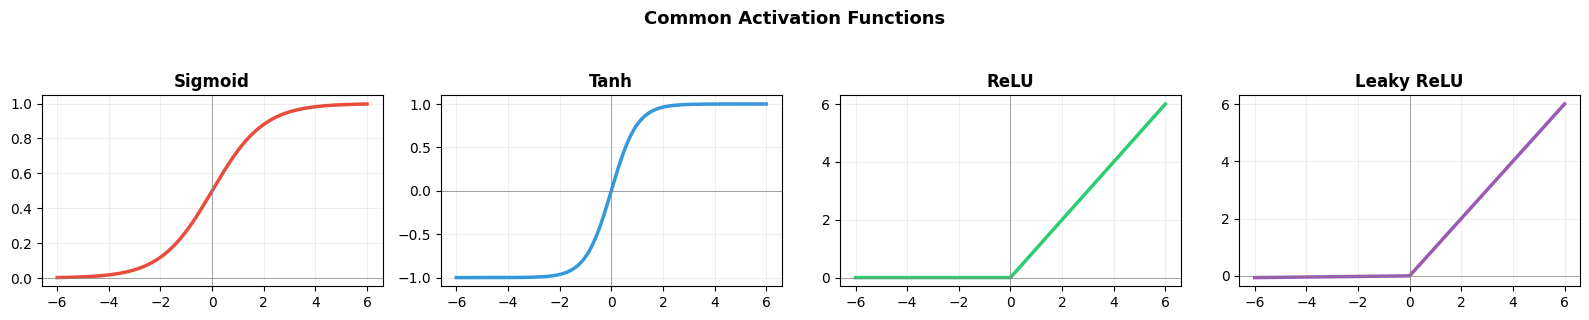

In [16]:
# --- Activation functions ---
z = np.linspace(-6, 6, 300)

activations = {
    'Sigmoid':  1 / (1 + np.exp(-z)),
    'Tanh':     np.tanh(z),
    'ReLU':     np.maximum(0, z),
    'Leaky ReLU': np.where(z > 0, z, 0.01 * z),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for ax, (name, values), color in zip(axes, activations.items(), colors):
    ax.plot(z, values, color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)
plt.suptitle('Common Activation Functions', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


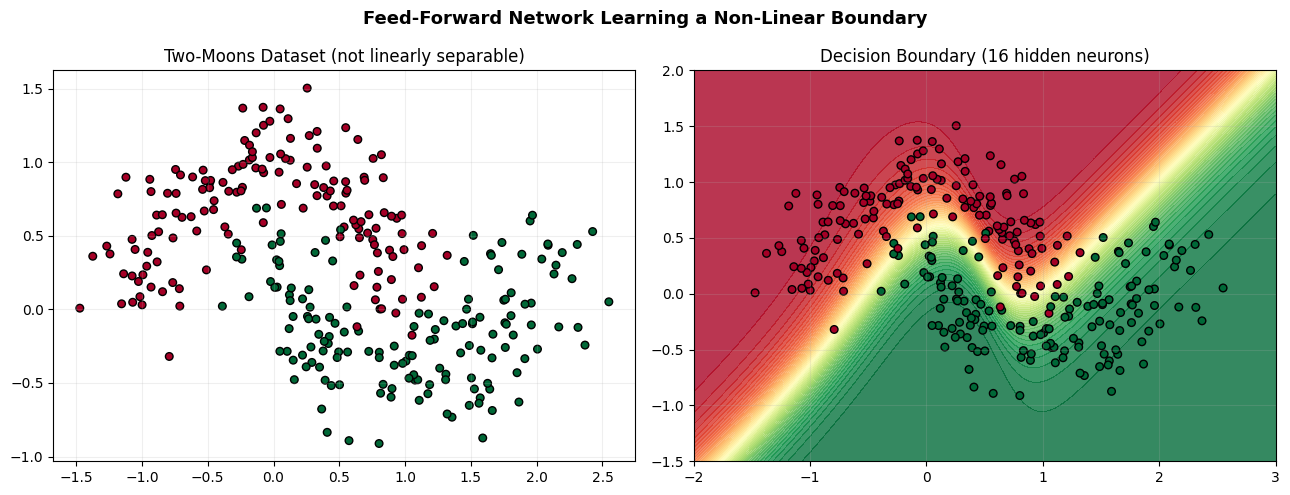

The hidden layer transforms the input into a new space where the classes ARE separable!


In [17]:
# --- Demonstration: hidden layers learn non-linear boundaries ---
# Create a "two moons" dataset that is NOT linearly separable
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# Train our MLP from scratch (reusing the class from §8)
mlp_moons = MLP(n_in=2, n_hidden=16, n_out=1, lr=2.0)
mlp_moons.fit(X_moons, y_moons.reshape(-1, 1), epochs=3000, verbose=False)

# Decision surface
xx2, yy2 = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300))
grid2 = np.c_[xx2.ravel(), yy2.ravel()]
zz2 = mlp_moons.forward(grid2).reshape(xx2.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlGn',
                edgecolors='black', s=30)
axes[0].set_title('Two-Moons Dataset (not linearly separable)')
axes[0].grid(True, alpha=0.2)

axes[1].contourf(xx2, yy2, zz2, levels=50, cmap='RdYlGn', alpha=0.8)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlGn',
                edgecolors='black', s=30)
axes[1].set_title('Decision Boundary (16 hidden neurons)')
axes[1].grid(True, alpha=0.2)

plt.suptitle('Feed-Forward Network Learning a Non-Linear Boundary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("The hidden layer transforms the input into a new space where the classes ARE separable!")


---
## 11. Generalization, Overfitting, and Stopping Criteria

**Generalization** = the model's ability to perform well on *unseen* data.

**Overfitting** = the model memorizes training data (including noise) and fails on new data. ANNs are especially prone to overfitting because they have many parameters.

### Signs of overfitting
- Training loss keeps decreasing, but **validation loss starts increasing**.
- Training accuracy ≫ test accuracy.

### Techniques to combat overfitting

| Technique | How it works |
|---|---|
| **Early stopping** | Stop training when validation loss stops improving |
| **L2 regularization** (weight decay) | Add $\frac{\lambda}{2}\|\mathbf{w}\|^2$ to the loss to penalize large weights |
| **L1 regularization** | Add $\lambda\|\mathbf{w}\|_1$ → promotes sparsity |
| **Dropout** | Randomly set a fraction of neurons to 0 during training |
| **Data augmentation** | Artificially increase the training set size |

Let's demonstrate overfitting and early stopping:


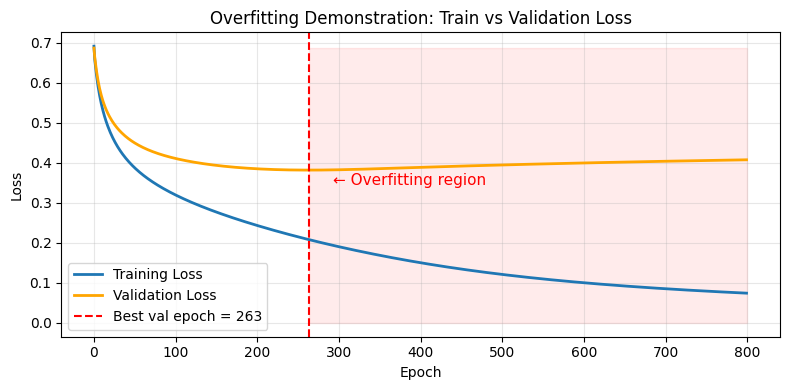

Best validation loss at epoch 263.
After that, validation loss rises while training loss keeps falling → OVERFITTING.
Early stopping would halt training at epoch 263.


In [18]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a small dataset where overfitting is easy to trigger
np.random.seed(42)
X_clf, y_clf = make_classification(n_samples=150, n_features=20,
                                    n_informative=5, n_redundant=5,
                                    random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Build MLP that can overfit (many hidden neurons relative to data)
class MLPOverfit:
    def __init__(self, n_in, n_hidden, n_out, lr=0.01):
        self.W1 = np.random.randn(n_in, n_hidden) * np.sqrt(2.0/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_out) * np.sqrt(2.0/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = 1/(1+np.exp(-np.clip(self.z1,-500,500)))
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = 1/(1+np.exp(-np.clip(self.z2,-500,500)))
        return self.a2

    def loss(self, y_pred, y_true):
        y_true = y_true.reshape(-1,1)
        eps = 1e-8
        return -np.mean(y_true*np.log(y_pred+eps) + (1-y_true)*np.log(1-y_pred+eps))

    def backward(self, X, y):
        y = y.reshape(-1,1)
        m = X.shape[0]
        d2 = (self.a2 - y) * self.a2 * (1-self.a2)
        d1 = (d2 @ self.W2.T) * self.a1 * (1-self.a1)
        self.W2 -= self.lr * (self.a1.T @ d2) / m
        self.b2 -= self.lr * np.sum(d2, axis=0, keepdims=True) / m
        self.W1 -= self.lr * (X.T @ d1) / m
        self.b1 -= self.lr * np.sum(d1, axis=0, keepdims=True) / m

net = MLPOverfit(n_in=20, n_hidden=64, n_out=1, lr=1.0)

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_epoch = 0
patience = 50
patience_counter = 0

for ep in range(800):
    # Train
    out_tr = net.forward(X_tr)
    tl = net.loss(out_tr, y_tr)
    train_losses.append(tl)
    net.backward(X_tr, y_tr)

    # Validate (no weight update!)
    out_val = net.forward(X_val)
    vl = net.loss(out_val, y_val)
    val_losses.append(vl)

    # Early stopping logic
    if vl < best_val_loss:
        best_val_loss = vl
        best_epoch = ep
        patience_counter = 0
    else:
        patience_counter += 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Training Loss', lw=2)
ax.plot(val_losses, label='Validation Loss', lw=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', lw=1.5, label=f'Best val epoch = {best_epoch}')
ax.fill_betweenx([0, max(val_losses)], best_epoch, 800, alpha=0.08, color='red')
ax.text(best_epoch + 30, max(val_losses)*0.5, '← Overfitting region', color='red', fontsize=11)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Overfitting Demonstration: Train vs Validation Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best validation loss at epoch {best_epoch}.")
print(f"After that, validation loss rises while training loss keeps falling → OVERFITTING.")
print(f"Early stopping would halt training at epoch {best_epoch}.")


---
## 12. Hyperparameters and Tuning

Hyperparameters are values set *before* training begins (not learned from data).

### Key hyperparameters in ANNs

| Hyperparameter | Typical range | Effect |
|---|---|---|
| **Learning rate** $\eta$ | $10^{-4}$ – $10^{-1}$ | Too high → diverge; too low → slow |
| **Hidden layers / neurons** | 1–5 layers, 16–512 neurons | More = more capacity (but overfitting risk) |
| **Momentum** $\alpha$ | 0.0 – 0.99 | Smooths gradient updates |
| **Batch size** | 16, 32, 64, 128 | Small = noisy, large = stable |
| **Regularization** $\lambda$ | $10^{-5}$ – $10^{-1}$ | Controls weight magnitude |
| **Epochs** | 50 – 1000+ | Combined with early stopping |
| **Activation function** | ReLU, sigmoid, tanh | ReLU default for hidden layers |

### Tuning strategies
1. **Grid Search**: Exhaustively try every combination.
2. **Random Search**: Sample hyperparameters randomly (often more efficient).
3. **Bayesian Optimization**: Use a surrogate model to guide the search.

Let's demonstrate the effect of learning rate:


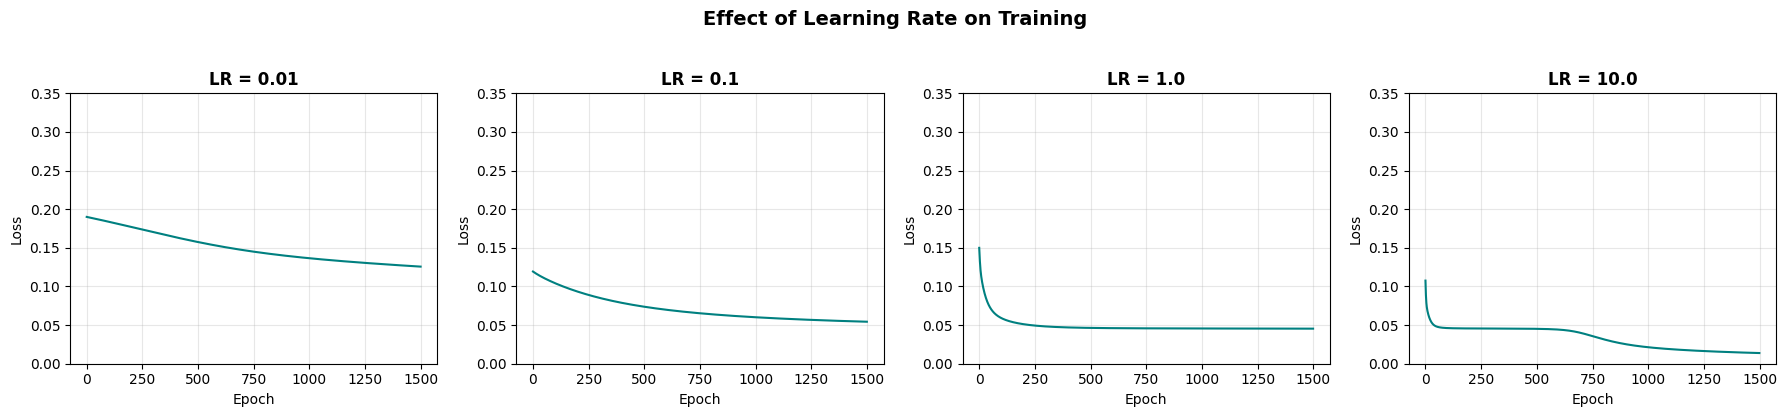

• LR=0.01: converges slowly but steadily
• LR=0.1:  good convergence speed
• LR=1.0:  fast but may oscillate
• LR=10.0: too high — diverges or oscillates wildly


In [19]:
# Effect of learning rate on training convergence
from sklearn.datasets import make_moons

np.random.seed(42)
X_hp, y_hp = make_moons(300, noise=0.2, random_state=42)

learning_rates = [0.01, 0.1, 1.0, 10.0]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, lr_val in zip(axes, learning_rates):
    net_hp = MLP(n_in=2, n_hidden=8, n_out=1, lr=lr_val)
    net_hp.fit(X_hp, y_hp.reshape(-1,1), epochs=1500, verbose=False)

    ax.plot(net_hp.losses, lw=1.5, color='teal')
    ax.set_title(f'LR = {lr_val}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_ylim(0, 0.35)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Learning Rate on Training', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("• LR=0.01: converges slowly but steadily")
print("• LR=0.1:  good convergence speed")
print("• LR=1.0:  fast but may oscillate")
print("• LR=10.0: too high — diverges or oscillates wildly")


In [20]:
# Grid search demonstration using scikit-learn
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=500, random_state=42, early_stopping=True))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(16,), (32,), (16, 16)],
    'mlp__learning_rate_init': [0.001, 0.01],
    'mlp__alpha': [0.0001, 0.01],  # L2 regularization
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_hp, y_hp)

print("Grid Search Results:")
print(f"  Best params:   {grid.best_params_}")
print(f"  Best CV score: {grid.best_score_:.4f}")

import pandas as pd
results_df = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
print("\nAll configurations ranked:")
print(results_df.to_string(index=False))


Grid Search Results:
  Best params:   {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (16,), 'mlp__learning_rate_init': 0.01}
  Best CV score: 0.8567

All configurations ranked:
                                                                                       params  mean_test_score  rank_test_score
    {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (16,), 'mlp__learning_rate_init': 0.01}         0.856667                1
 {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (16, 16), 'mlp__learning_rate_init': 0.01}         0.856667                1
      {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (16,), 'mlp__learning_rate_init': 0.01}         0.856667                1
   {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (16, 16), 'mlp__learning_rate_init': 0.01}         0.856667                1
      {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (32,), 'mlp__learning_rate_init': 0.01}         0.833333                5
    {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes'

---
## 13. Culminating Example: Facial Recognition (30×32 Image)

We'll build a complete facial-recognition pipeline using the **Olivetti Faces** dataset from AT&T Laboratories Cambridge. This is a real dataset containing grayscale face images.

### About the dataset
- **400 images** of **40 different people** (10 images per person).
- Original resolution: 64×64 pixels.
- We will **resize each image to 30×32** (= 960 pixels) to match the classic Mitchell textbook example.

### Pipeline overview
1. Load and resize the faces to 30×32.
2. Visualize sample faces.
3. Flatten each image into a 960-dimensional feature vector.
4. Split into train / test sets.
5. Train an MLP from scratch (backpropagation with momentum).
6. Train a second model using `scikit-learn` for comparison.
7. Evaluate accuracy and visualize learned hidden-layer weights.


In [21]:
from sklearn.datasets import fetch_olivetti_faces
from skimage.transform import resize

# 1. Load the Olivetti Faces dataset
olivetti = fetch_olivetti_faces()
images_64 = olivetti.images     # shape: (400, 64, 64)
labels    = olivetti.target     # shape: (400,) — values 0..39

print(f"Original dataset:  {images_64.shape[0]} images, each {images_64.shape[1]}×{images_64.shape[2]} pixels")
print(f"Number of classes:  {len(np.unique(labels))} people")

# 2. Resize every image from 64×64 → 30×32
images_30x32 = np.array([resize(img, (30, 32), anti_aliasing=True) for img in images_64])
print(f"Resized dataset:   {images_30x32.shape[0]} images, each {images_30x32.shape[1]}×{images_30x32.shape[2]} pixels")
print(f"Features per image: {30*32} = 960")


Original dataset:  400 images, each 64×64 pixels
Number of classes:  40 people
Resized dataset:   400 images, each 30×32 pixels
Features per image: 960 = 960


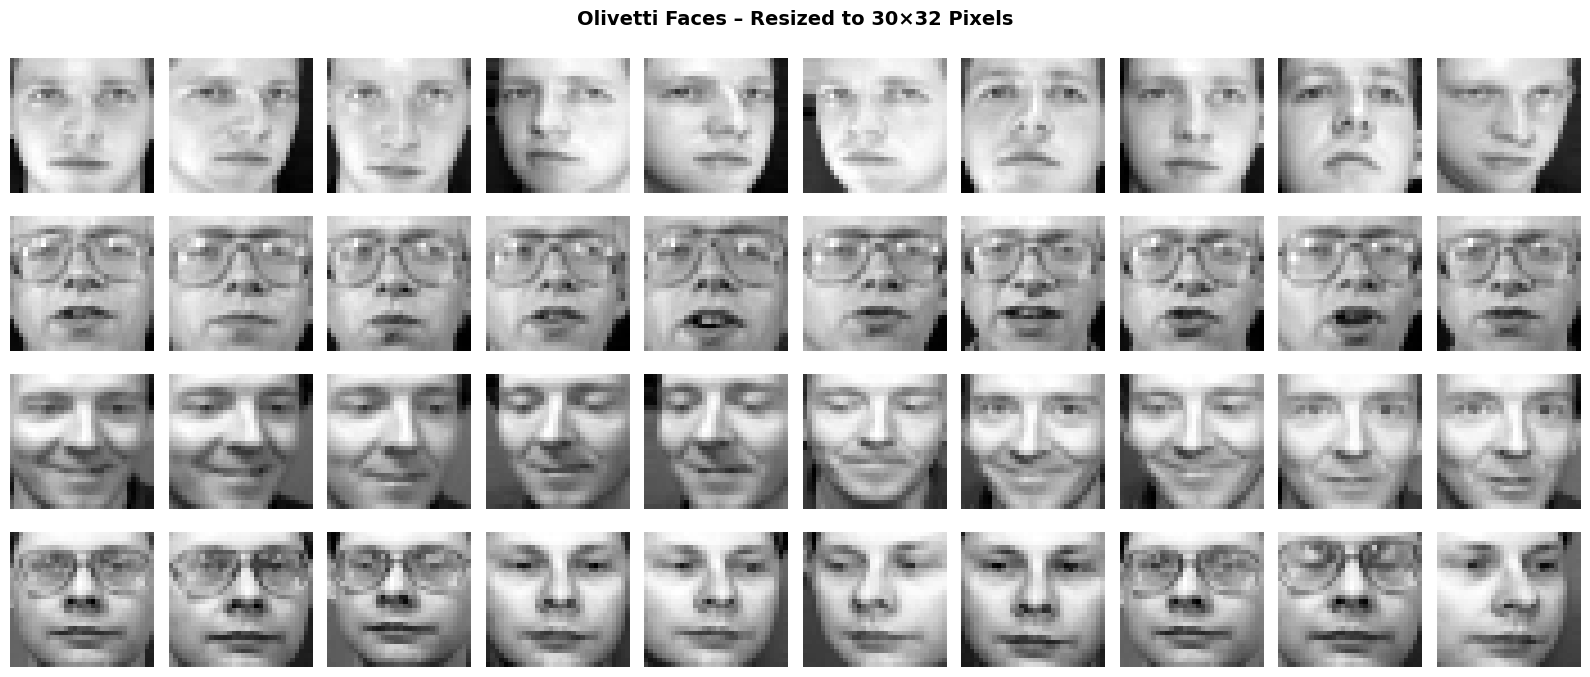

In [22]:
# 3. Visualize sample faces
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for person_id in range(4):
    person_imgs = images_30x32[labels == person_id]
    for j in range(10):
        ax = axes[person_id, j]
        ax.imshow(person_imgs[j], cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'Person {person_id}', fontsize=10, rotation=0, labelpad=50)

plt.suptitle('Olivetti Faces – Resized to 30×32 Pixels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [23]:
# 4. Flatten & Split
X_faces = images_30x32.reshape(400, -1)   # (400, 960)
y_faces = labels                           # (400,)

# Use first 8 images per person for training, last 2 for testing (stratified)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_faces, y_faces, test_size=0.2, stratify=y_faces, random_state=42)

print(f"Training set: {X_train_f.shape}")
print(f"Test set:     {X_test_f.shape}")


Training set: (320, 960)
Test set:     (80, 960)


In [24]:
# 5. Build an MLP from scratch with backpropagation + momentum for multi-class classification

class MLPFaces:
    """Multi-class MLP with softmax output, backprop, and momentum."""

    def __init__(self, n_in, n_hidden, n_out, lr=0.01, momentum=0.9):
        scale1 = np.sqrt(2.0 / n_in)
        scale2 = np.sqrt(2.0 / n_hidden)
        self.W1 = np.random.randn(n_in, n_hidden) * scale1
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_out) * scale2
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
        self.mom = momentum
        # Velocity terms for momentum
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)
        self.train_losses = []
        self.train_accs = []

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def relu_deriv(z):
        return (z > 0).astype(float)

    @staticmethod
    def softmax(z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.softmax(self.z2)
        return self.a2

    def cross_entropy_loss(self, y_pred, y_true_onehot):
        eps = 1e-8
        return -np.mean(np.sum(y_true_onehot * np.log(y_pred + eps), axis=1))

    def backward(self, X, y_onehot):
        m = X.shape[0]
        # Output gradient (softmax + cross-entropy simplifies to this)
        d2 = (self.a2 - y_onehot) / m
        # Hidden gradient
        d1 = (d2 @ self.W2.T) * self.relu_deriv(self.z1)

        # Compute raw gradients
        gW2 = self.a1.T @ d2
        gb2 = np.sum(d2, axis=0, keepdims=True)
        gW1 = X.T @ d1
        gb1 = np.sum(d1, axis=0, keepdims=True)

        # Update with momentum: v = α*v + η*grad; w -= v
        self.vW2 = self.mom * self.vW2 + self.lr * gW2
        self.vb2 = self.mom * self.vb2 + self.lr * gb2
        self.vW1 = self.mom * self.vW1 + self.lr * gW1
        self.vb1 = self.mom * self.vb1 + self.lr * gb1

        self.W2 -= self.vW2
        self.b2 -= self.vb2
        self.W1 -= self.vW1
        self.b1 -= self.vb1

    def fit(self, X, y, epochs=300):
        n_classes = len(np.unique(y))
        # One-hot encode labels
        y_onehot = np.eye(n_classes)[y]

        for ep in range(epochs):
            # Mini-batch SGD (batch_size=32)
            indices = np.random.permutation(len(X))
            for start in range(0, len(X), 32):
                idx = indices[start:start+32]
                out = self.forward(X[idx])
                self.backward(X[idx], y_onehot[idx])

            # Epoch-level metrics
            out_all = self.forward(X)
            loss = self.cross_entropy_loss(out_all, y_onehot)
            acc = np.mean(np.argmax(out_all, axis=1) == y)
            self.train_losses.append(loss)
            self.train_accs.append(acc)

            if ep % 50 == 0:
                print(f"  Epoch {ep:4d} | Loss: {loss:.4f} | Acc: {acc:.4f}")

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

# Train
np.random.seed(42)
net_faces = MLPFaces(n_in=960, n_hidden=100, n_out=40, lr=0.01, momentum=0.9)
print("Training MLP (from scratch) on Olivetti Faces 30×32...")
print(f"Architecture: 960 → 100 (ReLU) → 40 (Softmax)")
print(f"Optimizer: SGD with momentum=0.9, lr=0.01, batch_size=32\n")
net_faces.fit(X_train_f, y_train_f, epochs=300)


Training MLP (from scratch) on Olivetti Faces 30×32...
Architecture: 960 → 100 (ReLU) → 40 (Softmax)
Optimizer: SGD with momentum=0.9, lr=0.01, batch_size=32

  Epoch    0 | Loss: 3.6854 | Acc: 0.0719
  Epoch   50 | Loss: 0.2894 | Acc: 0.9906
  Epoch  100 | Loss: 0.0546 | Acc: 1.0000
  Epoch  150 | Loss: 0.0259 | Acc: 1.0000
  Epoch  200 | Loss: 0.0164 | Acc: 1.0000
  Epoch  250 | Loss: 0.0118 | Acc: 1.0000



=== From-Scratch MLP ===
Test Accuracy: 96.25%


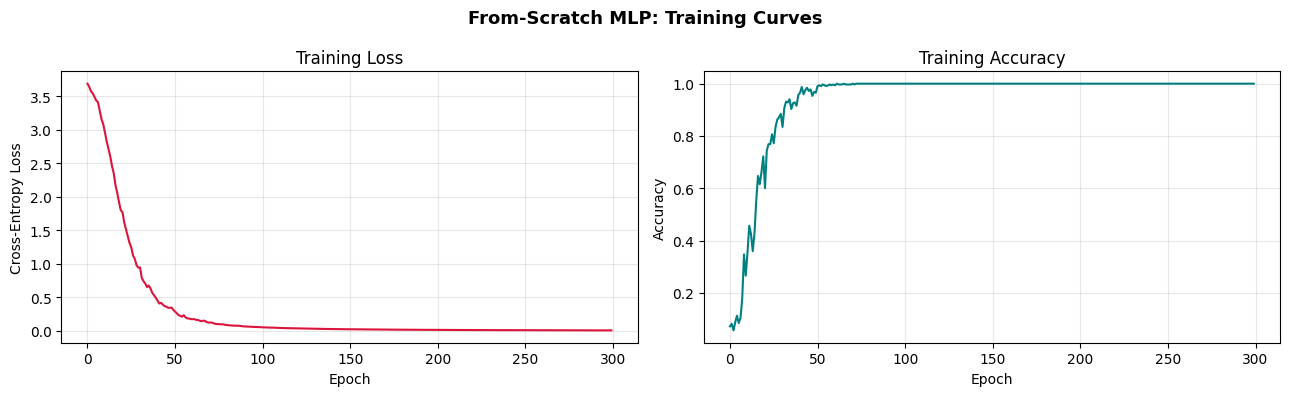

In [25]:
# 6. Evaluate the from-scratch model
y_pred_scratch = net_faces.predict(X_test_f)
acc_scratch = np.mean(y_pred_scratch == y_test_f)
print(f"\n=== From-Scratch MLP ===")
print(f"Test Accuracy: {acc_scratch * 100:.2f}%")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(net_faces.train_losses, color='crimson', lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(net_faces.train_accs, color='teal', lw=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy'); axes[1].grid(True, alpha=0.3)

plt.suptitle('From-Scratch MLP: Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [26]:
# 7. Scikit-learn MLPClassifier for comparison
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_f)
X_test_sc = scaler.transform(X_test_f)

mlp_sk = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)
mlp_sk.fit(X_train_sc, y_train_f)
y_pred_sk = mlp_sk.predict(X_test_sc)
acc_sk = np.mean(y_pred_sk == y_test_f)

print(f"=== Scikit-learn MLP ===")
print(f"Test Accuracy: {acc_sk * 100:.2f}%")
print(f"Converged in {mlp_sk.n_iter_} iterations\n")
print("Classification Report (top 10 classes shown):")
print(classification_report(y_test_f, y_pred_sk, zero_division=0))


=== Scikit-learn MLP ===
Test Accuracy: 91.25%
Converged in 18 iterations

Classification Report (top 10 classes shown):
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      0.50      0.67         2
          13       1.00      0.50      0.67         2
          14       1.00      1.00      1.00         2
          15  

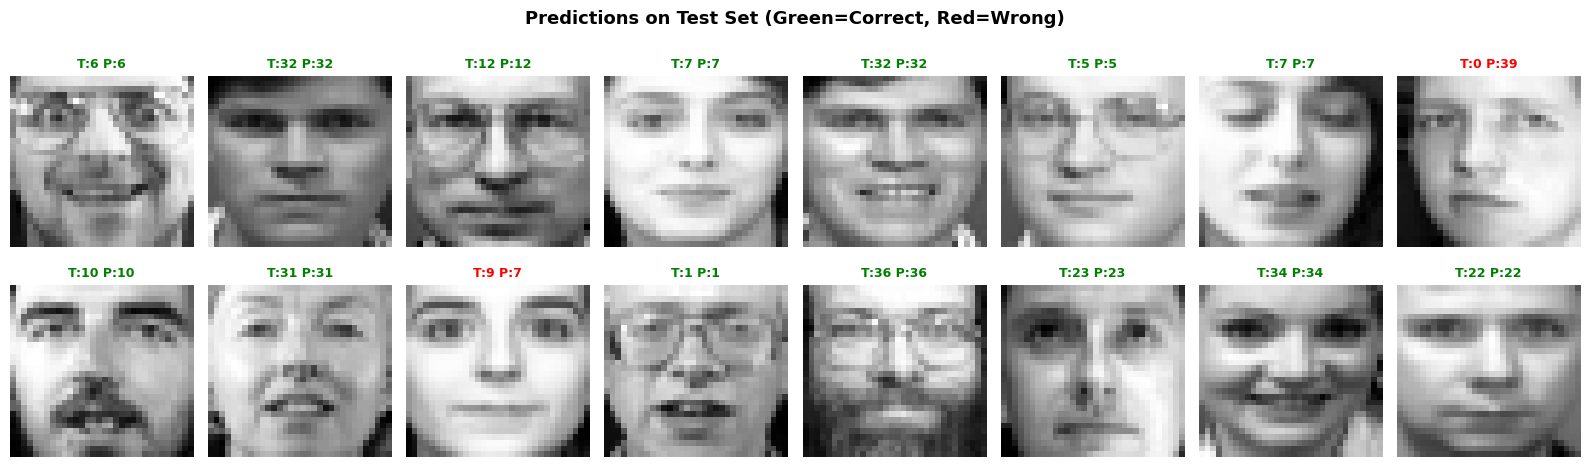

In [27]:
# 8. Visualize some predictions
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
sample_indices = np.random.choice(len(X_test_f), 16, replace=False)

for i, idx in enumerate(sample_indices):
    ax = axes[i // 8, i % 8]
    ax.imshow(X_test_f[idx].reshape(30, 32), cmap='gray')
    true_label = y_test_f[idx]
    pred_label = y_pred_sk[idx]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'T:{true_label} P:{pred_label}', fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predictions on Test Set (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


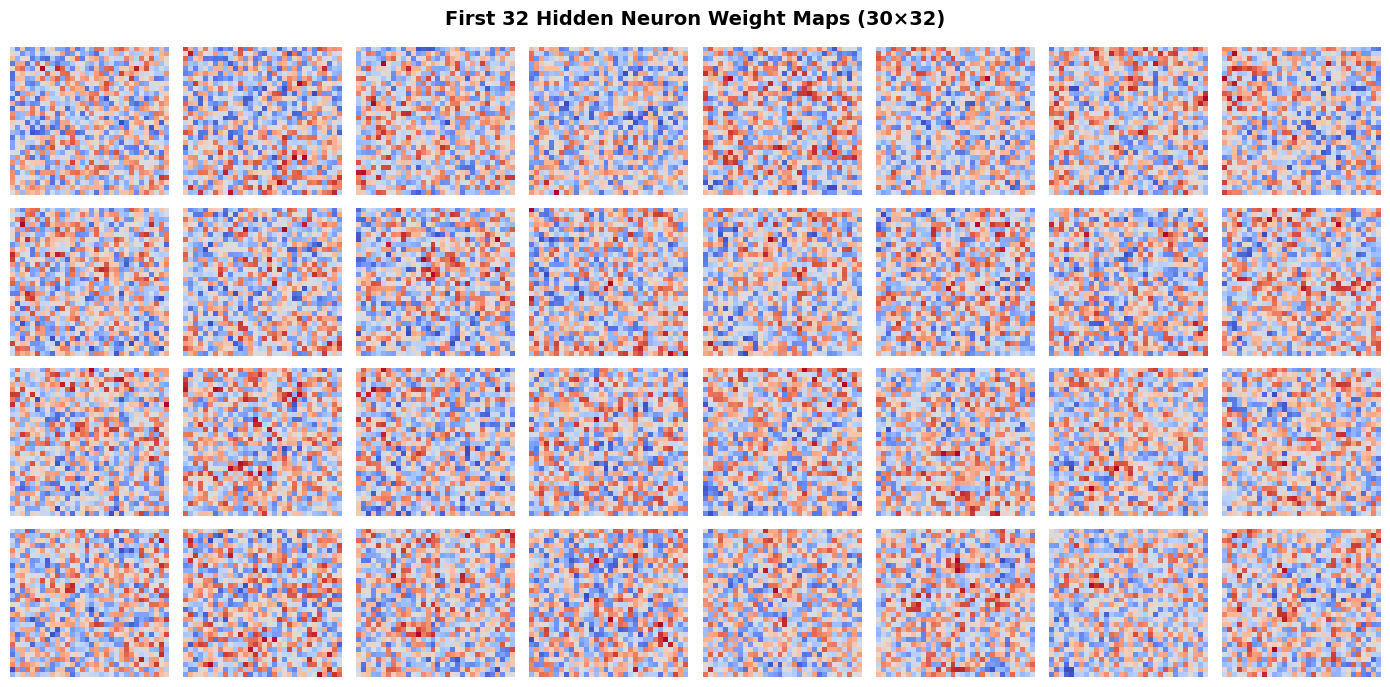

Each image shows what pixel pattern a hidden neuron responds to most strongly.
Bright regions = positive weights (excitatory); dark = negative (inhibitory).


In [28]:
# 9. Visualize what hidden neurons "see" (learned weight patterns)
# Each column of W1 (shape 960×100) can be reshaped into a 30×32 "receptive field"
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < mlp_sk.coefs_[0].shape[1]:
        w = mlp_sk.coefs_[0][:, i].reshape(30, 32)
        ax.imshow(w, cmap='coolwarm', interpolation='nearest')
    ax.axis('off')

plt.suptitle('First 32 Hidden Neuron Weight Maps (30×32)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each image shows what pixel pattern a hidden neuron responds to most strongly.")
print("Bright regions = positive weights (excitatory); dark = negative (inhibitory).")


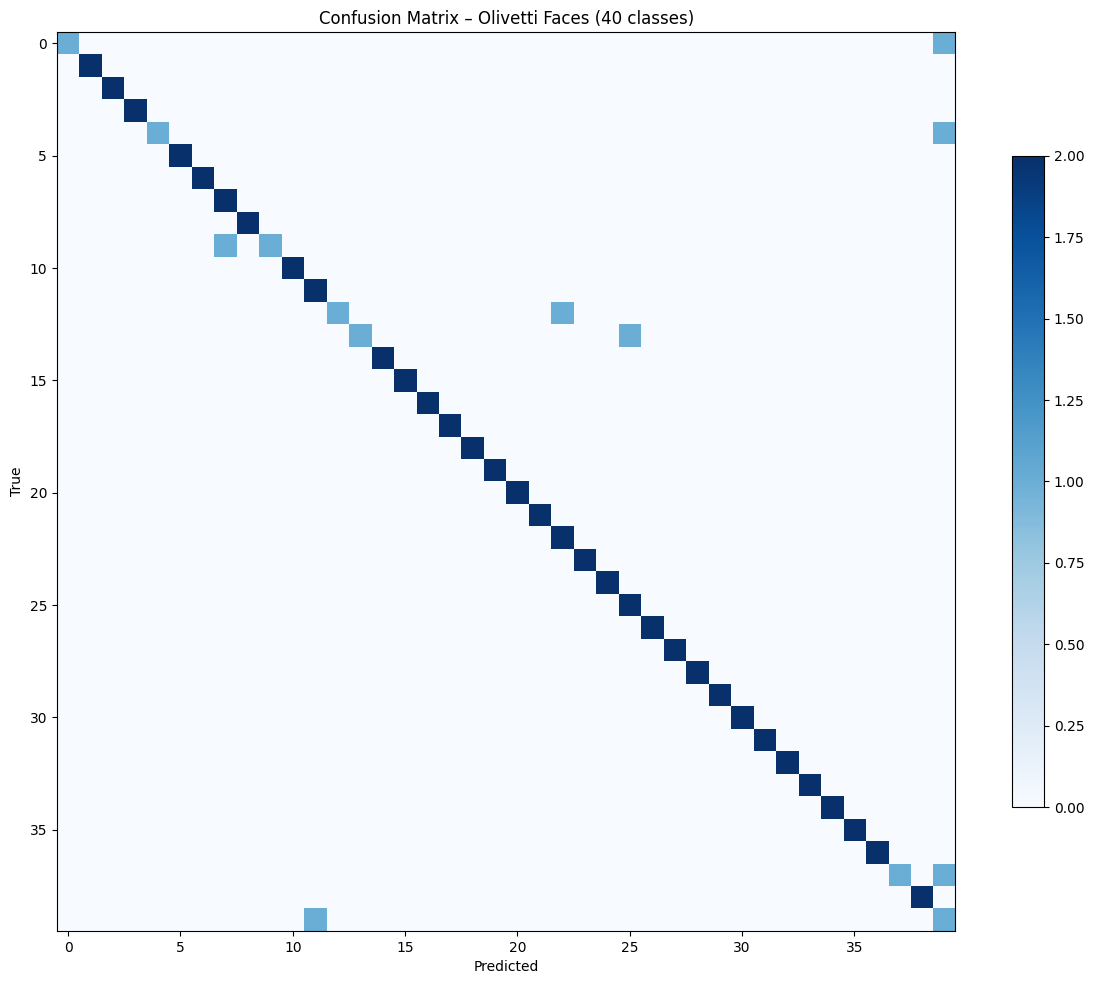


SUMMARY
Dataset:          Olivetti Faces (400 images, 40 people)
Image size:       30 × 32 = 960 features
Architecture:     960 → 100 (ReLU) → 40 (Softmax)
From-scratch acc: 96.2%
Sklearn acc:      91.2%


In [29]:
# 10. Confusion matrix heatmap
cm = confusion_matrix(y_test_f, y_pred_sk)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix – Olivetti Faces (40 classes)')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"{'='*50}")
print(f"Dataset:          Olivetti Faces (400 images, 40 people)")
print(f"Image size:       30 × 32 = 960 features")
print(f"Architecture:     960 → 100 (ReLU) → 40 (Softmax)")
print(f"From-scratch acc: {acc_scratch*100:.1f}%")
print(f"Sklearn acc:      {acc_sk*100:.1f}%")
print(f"{'='*50}")


---
## Conclusion

In this notebook we covered the full arc of Artificial Neural Networks:

1. **Biological motivation** — how neurons inspired the artificial model.
2. **Perceptrons** — the simplest neural network; limited to linear boundaries.
3. **Training rules** — the perceptron rule, delta rule, and gradient descent.
4. **Stochastic gradient descent** — trading accuracy per step for speed.
5. **Backpropagation** — extending gradient descent to multi-layer networks via the chain rule.
6. **Momentum** — accelerating convergence and escaping local minima.
7. **Feed-forward networks** — adding hidden layers for non-linear power.
8. **Overfitting & regularization** — controlling model complexity.
9. **Hyperparameter tuning** — systematic search for the best configuration.
10. **Facial recognition** — a real-world application on the Olivetti Faces dataset with 30×32 images.

### Where to go next
- **Convolutional Neural Networks (CNNs)** — preserve spatial structure in images.
- **Recurrent Neural Networks (RNNs)** — handle sequential data.
- **Transformers** — attention-based architectures powering modern NLP and vision.
